<a href="https://colab.research.google.com/github/Psyche-1/goit-ds-hw/blob/main/Hw11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.datasets import imdb

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

In [18]:
import matplotlib.pyplot as plt

In [11]:
max_features = 10000
max_len = 200
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

X_all = np.concatenate((X_train, X_test), axis=0)
y_all = np.concatenate((y_train, y_test), axis=0)

word_index = imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(text_indices):
    return " ".join([reverse_word_index.get(i, "?") for i in text_indices])

decoded_reviews = [decode_review(sms) for sms in X_all]

In [3]:
df = pd.DataFrame({
    "review": decoded_reviews,
    "sentiment": y_all
})
df

,review,sentiment
0,<START> this film was just brilliant casting l...,1
1,<START> big hair big boobs bad music and a gia...,0
2,<START> this has to be one of the worst films ...,0
3,<START> the <UNK> <UNK> at storytelling the tr...,1
4,<START> worst mistake of my life br br i picke...,0
...,...,...
49995,<START> the book is better than the film mostl...,1
49996,<START> the largest crowd to ever see a wrestl...,1
49997,<START> i suppose that to say this is an all o...,0
49998,<START> in love 2 is the third movie it seemed...,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB


In [5]:
df.isnull().sum()

,0
review,0
sentiment,0


In [6]:
df.describe(include='all')

,review,sentiment
count,50000,50000.000000
unique,49579,NaN
top,<START> loved today's show it was a variety an...,NaN
freq,5,NaN
mean,NaN,0.500000
std,NaN,0.500005
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.500000
75%,NaN,1.000000


In [7]:
df['review'].apply(len).describe()

,review
count,50000.000000
mean,1233.231880
std,917.862691
min,38.000000
25%,669.000000
50%,920.000000
75%,1496.000000
max,12854.000000


In [8]:
df.duplicated().sum()

np.int64(421)

In [10]:
df.drop_duplicates(subset=['review'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [28]:
tokenizer = Tokenizer(num_words=max_features, oov_token="<UNK>")
tokenizer.fit_on_texts(df['review'])
sequences = tokenizer.texts_to_sequences(df['review'])
X_padded = pad_sequences(sequences, maxlen=max_len, padding='pre', truncating='pre')
y_labels = df['sentiment'].values
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

In [13]:
X_train.shape

(39663, 200)

In [14]:
X_test.shape

(9916, 200)

In [29]:
rnn_model = Sequential(name="SimpleRNN_Model")

rnn_model.add(Embedding(input_dim=max_features, output_dim=64, input_length=max_len))
rnn_model.add(SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,\
    verbose=1
)

Epoch 1/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.5292 - loss: 0.6925 - val_accuracy: 0.5816 - val_loss: 0.6716
Epoch 2/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6120 - loss: 0.6438 - val_accuracy: 0.6295 - val_loss: 0.6216
Epoch 3/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6964 - loss: 0.5691 - val_accuracy: 0.6803 - val_loss: 0.5889
Epoch 4/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7534 - loss: 0.4983 - val_accuracy: 0.6653 - val_loss: 0.6155
Epoch 5/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7407 - loss: 0.5135 - val_accuracy: 0.6733 - val_loss: 0.6065


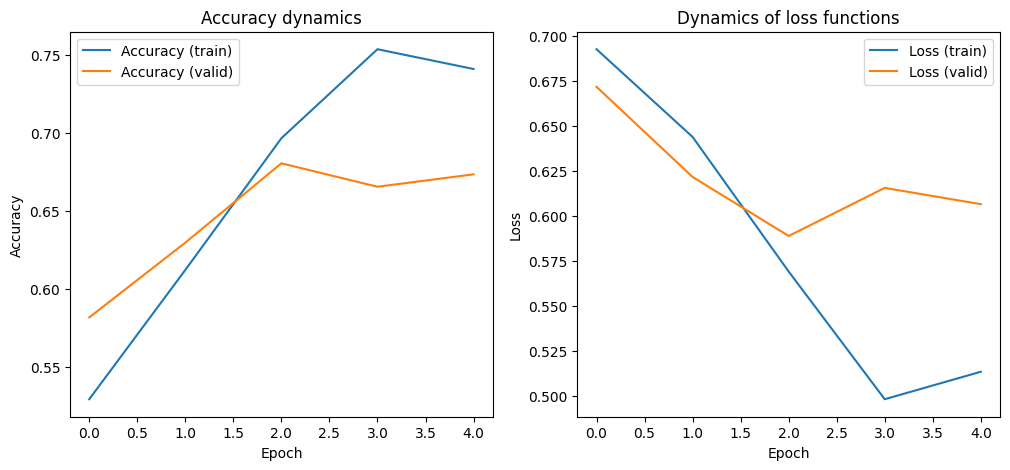

In [31]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['accuracy'], label='Accuracy (train)')
plt.plot(rnn_history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['loss'], label='Loss (train)')
plt.plot(rnn_history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [32]:
test_loss, test_accuracy = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 67%
Test loss: 0.6067


In [35]:
lstm_model = Sequential(name="LSTM_Model")

lstm_model = Sequential(name="LSTM_Improved")
lstm_model.add(Embedding(input_dim=max_features, output_dim=64, input_length=max_len))
lstm_model.add(LSTM(64, dropout=0.2))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "LSTM_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8186 - loss: 0.3938 - val_accuracy: 0.8781 - val_loss: 0.2958
Epoch 2/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8996 - loss: 0.2528 - val_accuracy: 0.8792 - val_loss: 0.2921
Epoch 3/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9259 - loss: 0.1940 - val_accuracy: 0.8796 - val_loss: 0.2975
Epoch 4/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9410 - loss: 0.1601 - val_accuracy: 0.8771 - val_loss: 0.3707
Epoch 5/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9502 - loss: 0.1376 - val_accuracy: 0.8772 - val_loss: 0.3929


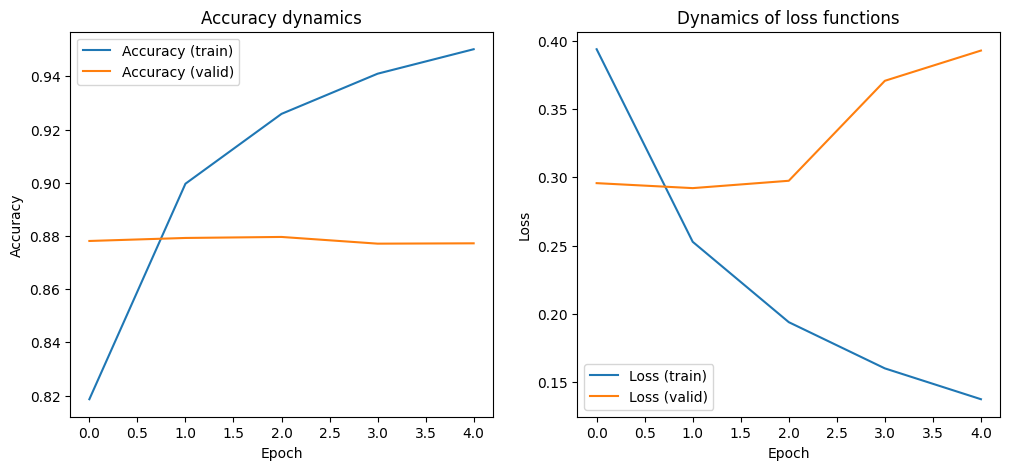

In [37]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'], label='Accuracy (train)')
plt.plot(lstm_history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='Loss (train)')
plt.plot(lstm_history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [38]:
test_loss, test_accuracy = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 87%
Test loss: 0.4015


In [40]:
bidi_model = Sequential(name="Bidirectional_LSTM_Model")

bidi_model.add(Embedding(input_dim=max_features, output_dim=128, input_length=max_len))

bidi_model.add(SpatialDropout1D(0.3))

bidi_model.add(Bidirectional(LSTM(64, dropout=0.2)))

bidi_model.add(Dense(1, activation='sigmoid'))

bidi_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bidi_model.summary()

Model: "Bidirectional_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

bidi_history = bidi_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.8130 - loss: 0.4060 - val_accuracy: 0.8761 - val_loss: 0.3009
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8965 - loss: 0.2601 - val_accuracy: 0.8797 - val_loss: 0.2982
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9204 - loss: 0.2097 - val_accuracy: 0.8750 - val_loss: 0.2962
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9347 - loss: 0.1749 - val_accuracy: 0.8839 - val_loss: 0.3042
Epoch 5/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9477 - loss: 0.1440 - val_accuracy: 0.8834 - val_loss: 0.3362


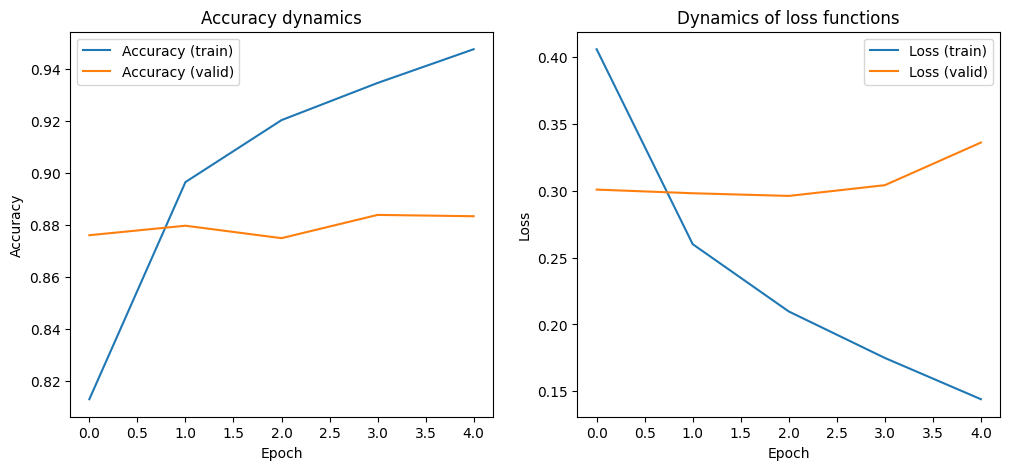

In [42]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(bidi_history.history['accuracy'], label='Accuracy (train)')
plt.plot(bidi_history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(bidi_history.history['loss'], label='Loss (train)')
plt.plot(bidi_history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [43]:
test_loss, test_accuracy = bidi_model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 87%
Test loss: 0.2991


In [45]:
deep_model = Sequential(name="Deep_LSTM_Model")

deep_model.add(Embedding(input_dim=max_features, output_dim=128, input_length=max_len))
deep_model.add(SpatialDropout1D(0.3))

deep_model.add(LSTM(64, return_sequences=True, dropout=0.2))

deep_model.add(LSTM(32, dropout=0.2))

deep_model.add(Dense(32, activation='relu'))
deep_model.add(Dropout(0.3))

deep_model.add(Dense(1, activation='sigmoid'))

deep_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()

Model: "Deep_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

deep_history = deep_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.7877 - loss: 0.4448 - val_accuracy: 0.8374 - val_loss: 0.3761
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8869 - loss: 0.2872 - val_accuracy: 0.8753 - val_loss: 0.3191
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9137 - loss: 0.2273 - val_accuracy: 0.8063 - val_loss: 0.4277
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9299 - loss: 0.1880 - val_accuracy: 0.8762 - val_loss: 0.3109
Epoch 5/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9435 - loss: 0.1554 - val_accuracy: 0.8785 - val_loss: 0.4023
Epoch 6/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9510 - loss: 0.1371 - val_accuracy: 0.8753 - val_loss: 0.3978


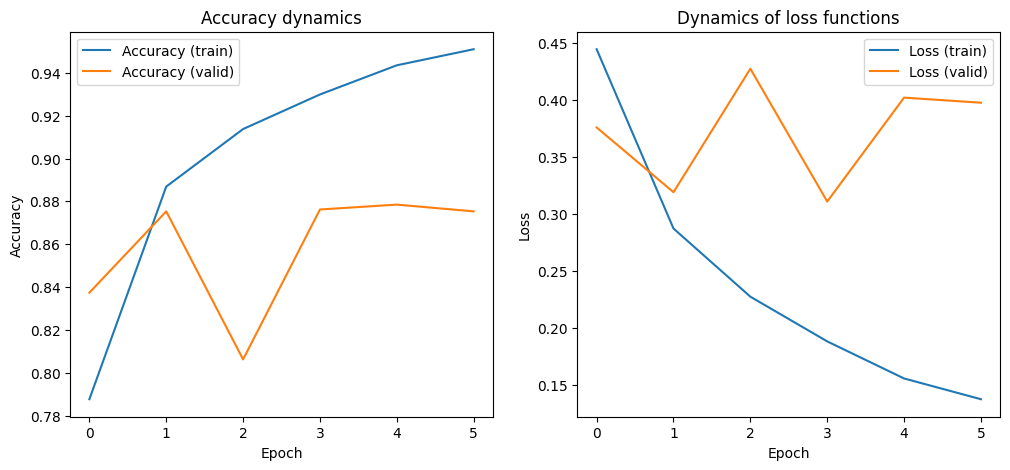

In [47]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(deep_history.history['accuracy'], label='Accuracy (train)')
plt.plot(deep_history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(deep_history.history['loss'], label='Loss (train)')
plt.plot(deep_history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [48]:
test_loss, test_accuracy = deep_model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 88%
Test loss: 0.3037


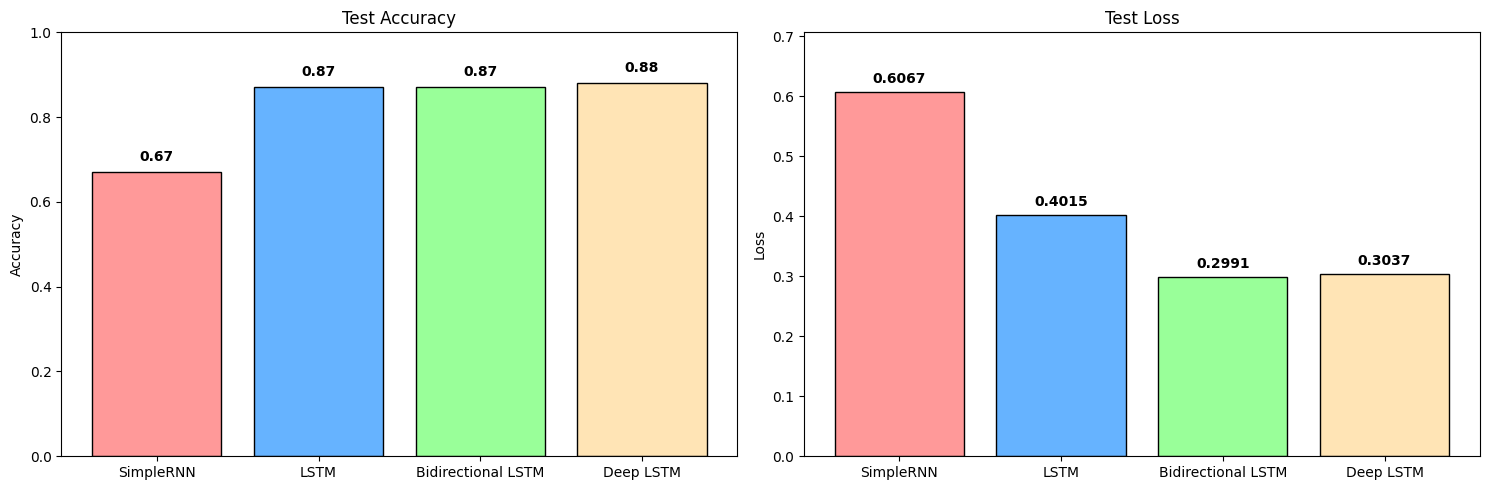

In [50]:
models = ['SimpleRNN', 'LSTM', 'Bidirectional LSTM', 'Deep LSTM']
accuracies = [0.67, 0.87, 0.87, 0.88]
losses = [0.6067, 0.4015, 0.2991, 0.3037]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

bars1 = ax1.bar(models, accuracies, color=['#ff9999','#66b3ff','#99ff99','moccasin'], edgecolor='black')
ax1.set_title('Test Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.0)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

bars2 = ax2.bar(models, losses, color=['#ff9999','#66b3ff','#99ff99','moccasin'], edgecolor='black')
ax2.set_title('Test Loss')
ax2.set_ylabel('Loss')
ax2.set_ylim(0, max(losses) + 0.1)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

На етапі підготовки були видалені дублікати.

## Порівняльний аналіз архітектур:
SimpleRNN (Accuracy: 67%, Loss: 0.6067)
Прості рекурентні мережі страждають від проблеми загасання градієнтів.

LSTM (Accuracy: 87%, Loss: 0.4015)
Успішно вирішує проблему загасання градієнту.

Bidirectional LSTM (Accuracy: 87%, Loss: 0.2991)
Значно знизила рівень втрат.

Deep LSTM (Accuracy: 88%, Loss: 0.3037) Показала найкращий результат точності серед усіх експериментів.

Для задач Sentiment Analysis класичні архітектури SimpleRNN є неефективними. Найбільш оптимальний баланс між швидкістю навчання, впевненістю передбачень та фінальною точністю демонструють Bidirectional LSTM та Deep LSTM